Was as a collaborator to this work.

# Setup and data loading

In [2]:
# This cell is complete: you don't need to change anything

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

def get_device():
    """Return the best available device: CUDA > MPS (Apple) > XLA (TPU) > CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device()
    except ImportError:
        pass
    return torch.device('cpu')

device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [3]:
# This cell is complete: you don't need to change anything

# load the data

transform = transforms.ToTensor()  # scales pixels to [0, 1]

train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# pin_memory speeds up host→GPU transfers; only meaningful for CUDA
pin = isinstance(device, torch.device) and device.type == 'cuda'

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=pin)

x_viz, y_viz = next(iter(DataLoader(train_dataset, batch_size=500)))

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 469, Test batches: 79


## Fixed seed - Setup

One thing that caught us early on: running the same training code twice gave slightly different loss curves and latent space plots each time. That made it hard to compare configurations fairly.

The reason might be that 3 things in a VAE are random by nature, as we learnt:
- the initial weights are randomly initialised
- the latent vector **z** is **sampled** at every forward pass (that is literally the point of a VAE)
- the DataLoader shuffles batches in a different order each run

Fixing a seed across torch, numpy & random makes all of these deterministic. It does not make the model better, it just makes the runs repeatable so we can compare apples to apples.

We used seed 42 - a common setup.

**Reference:**
- https://pytorch.org/docs/stable/notes/randomness.html
- https://medium.com/geekculture/the-story-behind-random-seed-42-in-machine-learning-b838c4ac290a#:~:text=What%20is%20the%20significance%20of%20random.seed(42)%20%3F


In [4]:
import random

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)


Random seed set to: 42


# Visualisations

The next cell contains four functions which make useful plots you should look at for each of your models.

In [5]:
# This cell is complete: you don't need to write anything here.

def plot_history(history):
    """
    Plot training and test loss curves from the dict returned by train_vae.
    Three subplots: total loss, reconstruction loss, and KL loss.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, (title, train_key, test_key) in zip(axes, [
        ("Total loss",          "train_loss",  "test_loss"),
        ("Reconstruction loss", "train_recon", "test_recon"),
        ("KL loss",             "train_kl",    "test_kl"),
    ]):
        ax.plot(epochs, history[train_key], label="train")
        ax.plot(epochs, history[test_key],  label="test")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_latent_points(encoder, images, labels):
    """
    Encode a batch of images and scatter-plot their mu values in latent space.
    Colours correspond to the 10 classes.
    If the latent space is more than 2D, only the first two latent dimensions are shown.
    """
    fig, ax = plt.subplots()

    was_training = encoder.training
    encoder.eval()
    with torch.no_grad():
        mu, _ = encoder(images.to(device))
    encoder.train(was_training)
    z = mu.cpu().numpy()

    # vmin/vmax of -0.5..9.5 centres each integer on its colour band
    cmap = plt.get_cmap('tab10')
    scatter = ax.scatter(z[:, 0], z[:, 1], c=labels.numpy(),
                         cmap=cmap, vmin=-0.5, vmax=9.5)
    fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, ticks=range(10))

    ax.set_xlabel("z[0]")
    ax.set_ylabel("z[1]")
    ax.set_aspect('equal', adjustable='box')
    plt.show()



def plot_latent_space(decoder, n=10, figsize=10):
    """
    Display a grid of sampled images - ie iterate over a grid
    in the latent space and for each point in the grid,
    decode that point to get an image, and view that image.
    This only works when the VAE latent space is size z=2.
    """

    assert decoder.latent_size == 2
    
    image_size = 28
    
    # we'll look at a grid of [-scale, +scale]^2.
    scale = 2.0 
    
    figure = np.zeros((image_size * n, image_size * n))
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    was_training = decoder.training
    decoder.eval()
    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
                x_decoded = decoder(z_sample).cpu().numpy()
                digit = x_decoded[0].reshape(image_size, image_size)
                figure[
                    i * image_size : (i + 1) * image_size,
                    j * image_size : (j + 1) * image_size,
                ] = digit
    decoder.train(was_training)

    plt.figure(figsize=(figsize, figsize))
    start_range = image_size // 2
    end_range = n * image_size + start_range
    pixel_range = np.arange(start_range, end_range, image_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys")
    # plt.savefig("vae_latent_space.pdf")
    plt.show()


def plot_reconstructions(model, images, max_images=10):
    """
    Encode a batch of images through the VAE and display originals
    alongside their reconstructions.
    Top row: original images.  Bottom row: reconstructions.
    At most max_images columns are shown.
    """
    n = min(max_images, images.size(0))
    images = images[:n]

    was_training = model.training
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(images.to(device))
    model.train(was_training)
    recon = recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    fig.text(0.01, 0.75, "Original",       va='center', rotation='vertical')
    fig.text(0.01, 0.25, "Reconstruction", va='center', rotation='vertical')

    for j in range(n):
        for row, img in enumerate([images[j], recon[j]]):
            axes[row, j].imshow(img.squeeze(), cmap='Greys')
            axes[row, j].axis('off')

    plt.tight_layout()
    plt.show()


# Task: complete the Encoder and Decoder

## Why this architecture?

The goal is to take a 28x28 image & squeeze it into a small latent vector then expand it back to 28x28. We used 3 convolutional layers in each direction that is a common & well tested choice for small image datasets like this.

### Encoder design

Input (1, 28, 28)
  - conv1: kernel=3, stride=2, padding=1 --> (k[0], 14, 14)
  - conv2: kernel=3, stride=2, padding=1 --> (k[1],  7,  7)
  - conv3: kernel=4, stride=1, padding=0 --> (k[2],  4,  4)
  - flatten                             --> (k[2] * 4 * 4,)
  - fc_mu      --> (latent_size,)
  - fc_log_var -->  (latent_size,)


**Why stride=2 for conv1 and conv2?**
Stride=2 halves the spatial size at each step -> this is the standard way to downsample in CNNs without needing a separate pooling layer. It keeps the downsampling learnable.

**Why kernel=4, stride=1, padding=0 for conv3?**
- By the time we reach the 3rd layer, the spatial size is already at 7x7 & we just need to reach 4x4. Using stride=1 means we scan every pixel carefully(no skipping!). 
- Kernel=4 with stride=1 and no padding takes 7 -> 4 mathematically. 
- We asked ourselves whether corner pixels get missed here -> the answer is slightly yes, but Fashion-MNIST images are centred and the corners are almost always empty black anyway so it has no practical effect.

**Why 2 separate linear heads (fc_mu and fc_log_var)?**
- A regular autoencoder maps the image to a single point. 
- A VAE maps it to a *distribution* specifically a Gaussian with mean & variance. The 2 heads are needed to output both parameters. 
- We output log-variance (not variance directly) because log-variance is unconstrained(can be any real number) which makes gradient-based optimisation more stable.

### Decoder design

- The decoder is the mirror image, it starts from the latent vector and builds the image back up using transposed convolutions (ConvTranspose2d).
- The final layer uses Sigmoid instead of ReLU because we need pixel values in [0, 1].
- output_padding=1 is needed in the 2nd & 3rd deconv layers to resolve size ambiguity in transposed convolutions without it, the output size can be off by 1 pixel.

**Reference: Conv2d and transposed convolutions:**
- https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

**Reference: VAE encoder/decoder architecture:**
- https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/
- https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73


In [6]:
class Encoder(nn.Module):
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        k = kernels
        self.latent_size = latent_size

        ## YOUR CODE HERE: create the layers
        # Convolution layers:
        # 28x28 -> 14x14 -> 7x7 -> 4x4
        self.conv1 = nn.Conv2d(1, k[0], kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(k[0], k[1], kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(k[1], k[2], kernel_size=4, stride=1, padding=0)

        # 2 separate outputs for the VAE:
        # 1-> mean, 1 for the log variance
        self.fc_mu = nn.Linear(flat_size, latent_size)
        self.fc_log_var = nn.Linear(flat_size, latent_size)


    def forward(self, x):
        ## YOUR CODE HERE: run the layers and return z_mu, z_log_var

        #conv layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        # Flatten -> to pass into linear layers
        x = torch.flatten(x, start_dim=1)
        z_mu = self.fc_mu(x)
        z_log_var = self.fc_log_var(x)

        return z_mu, z_log_var


class Decoder(nn.Module):
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        k = kernels
        self.latent_size = latent_size
        self._k2 = k[2]

        ## YOUR CODE HERE: create the layers
        self.fc = nn.Linear(latent_size, flat_size)

        #transpose conv layers:
        # 4x4 -> 7x7 -> 14x14 -> 28x28
        self.deconv1 = nn.ConvTranspose2d(k[2], k[1], kernel_size=4, stride=1, padding=0)
        self.deconv2 = nn.ConvTranspose2d(k[1], k[0], kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(k[0], 1, kernel_size=3, stride=2, padding=1, output_padding=1)


    def forward(self, z):
        ## YOUR CODE HERE: run the layers and return xhat

        x = self.fc(z)
        #reshape back to feature maps -> (batch, channels, 4, 4)
        x = x.view(-1, self._k2, 4, 4)

        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        xhat = torch.sigmoid(self.deconv3(x))

        return xhat

# Task: run the Encoder and Decoder stand-alone to make sure they work

Before training, it is a good idea to test the model structure on a small batch.

Here We:
1. pass a few images into the encoder
2. check the shapes of mu and log_var
3. pass 1 latent output into the decoder
4. check if the reconstruction returns to image shape

This is just a debugging step to make sure the pipeline is connected properly before training.


In [7]:
x = train_dataset.data[:10].unsqueeze(1).float() / 255.0 # first 10 images

## YOUR CODE HERE: 
# Call your Encoder (defined above, not yet trained) 
# to process this x, and print the shape of the result.
encoder = Encoder(kernels=(8, 16, 24), flat_size=24 * 4 * 4, latent_size=2)

# Then call your Decoder (defined above, not yet trained) 
# to process the result from above, and print the shape of the new result.
decoder = Decoder(kernels=(8, 16, 24), flat_size=24 * 4 * 4, latent_size=2)

# sending images through the encoder
mu, log_var = encoder(x)
print("mu shape:", mu.shape)
print("log_var shape:", log_var.shape)

#sending 1 latent o/p through the decoder
xhat = decoder(mu)
print("reconstruction shape:", xhat.shape)


mu shape: torch.Size([10, 2])
log_var shape: torch.Size([10, 2])
reconstruction shape: torch.Size([10, 1, 28, 28])


## A few extra sanity checks

Running a full 30 epoch training run only to find something was broken from the start wastes time. So, we added a few quick checks 1st.

### What we checked & why

**1.Input scaling check**
- As the raw dataset stores pixels as integers in [0, 255]. Our decoder's sigmoid o/p is in [0, 1]. 
- If the I/P is not scaled to match, the BCE loss behaves strangely because it expects both sides in [0, 1]. 
This check just confirms the division by 255 worked.

**2.Encoder output check**
- We printed the mean & std deviation of mu & log_var from an untrained encoder. 
- At this stage the values should be small & roughly centred around 0. If mu_std was something like 100 that would suggest there's some bug.

**3.Sampling and decoder output check**
- We manually applied the reparameterisation trick (z = mu + exp(0.5 * log_var) * epsilon) & passed the result through the decoder. 
- The key thing to check is that the reconstruction values stay in [0, 1]. The Sigmoid should enforce this, if we saw values outside that range, the Sigmoid is done incorrectly.

**4.Tiny batch overfit check**
- We took a batch of 32 images & ran 10 training steps. The loss should visibly drop even a small amount. 
- If it doesn't move at all it means the gradients are not flowing something is broken in the loss/backward pass.

In [8]:
#I/P scaling check
x_small = train_dataset.data[:5].unsqueeze(1).float()
print("Before scaling  -> min:", x_small.min().item(), "max:", x_small.max().item())

x_small = x_small / 255.0
print("After scaling   -> min:", x_small.min().item(), "max:", x_small.max().item())

Before scaling  -> min: 0.0 max: 255.0
After scaling   -> min: 0.0 max: 1.0


In [9]:
#encoder o/p check
mu_check, log_var_check = encoder(x_small)

print("mu mean:", round(mu_check.mean().item(), 4))
print("mu std:", round(mu_check.std().item(), 4))
print("log_var mean:", round(log_var_check.mean().item(), 4))
print("log_var std:", round(log_var_check.std().item(), 4))


mu mean: -0.0429
mu std: 0.0427
log_var mean: -0.0017
log_var std: 0.0366


In [10]:
# Sampling & decoder output check
with torch.no_grad():
    z_check = mu_check + torch.exp(0.5 * log_var_check) * torch.randn_like(mu_check)
    recon_check = decoder(z_check)

print("z mean:", round(z_check.mean().item(), 4))
print("z std :", round(z_check.std().item(), 4))
print("reconstruction min:", round(recon_check.min().item(), 4))
print("reconstruction max:", round(recon_check.max().item(), 4))


z mean: -0.2685
z std : 1.1715
reconstruction min: 0.3516
reconstruction max: 0.4814


In [ ]:
# We ran after make_vae and vae_loss 
#  #tiny-batch overfit check
# # We only run a few steps here, the goal is not perfect fitting.
# tiny_model = make_vae(kernels_per_layer=(8, 16, 24), flat_size=24 * 4 * 4, latent_size=2).to(device)
# tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1e-3)

# x_tiny = next(iter(train_loader))[0][:32].to(device)

# print("Tiny batch quick check:")
# for step in range(1, 11):
#     recon_tiny, mu_tiny, log_var_tiny = tiny_model(x_tiny)
#     tiny_loss, tiny_recon, tiny_kl = vae_loss(recon_tiny, x_tiny, mu_tiny, log_var_tiny, lmbda=1.0)
#     tiny_optimizer.zero_grad()
#     tiny_loss.backward()
#     tiny_optimizer.step()
#     if step in [1, 5, 10]:
#         print(f"step {step:2d} | total: {tiny_loss.item():.2f} | recon: {tiny_recon.item():.2f} | kl: {tiny_kl.item():.2f}")


Tiny batch quick check:
step  1 | total: 605.55 | recon: 605.55 | kl: 0.00
step  5 | total: 602.15 | recon: 602.14 | kl: 0.01
step 10 | total: 596.63 | recon: 596.54 | kl: 0.09


# Task: write a short note in this cell to explain the shapes you observe.

### Our observations

- The input batch has shape (10, 1, 28, 28)
  - 10 = number of images
  - 1 = grayscale channel
  - 28 x 28 = image height & width

- The encoder returns:
  - mu with shape (10, 2)
  - log_var with shape (10, 2)

This means each image is being mapped into a latent space of size 2. So instead of storing each image as one fixed point, the encoder stores the centre and spread of a small latent distribution.

- The decoder output has shape (10, 1, 28, 28).

That is what we want because the decoder should rebuild each latent vector back into an image with the same shape as the original I/P.

So overall the shape flow makes sense:

**image -> encoder -> latent values -> decoder -> reconstructed image**


# Task: complete the VAE

## Building the full VAE

Now I combine the encoder and decoder into one complete model.

The forward pass has 3 steps:

1. Encode the input image into mu and log_var
2. Sample a latent vector z using the reparameterisation trick
3. Decode z back into a reconstructed image

**VAE = Autoencoder + Sampling + KL regularisation**


In [12]:
class VAE(nn.Module):
    def __init__(self, kernels, flat_size, latent_size):
        super().__init__()
        self.encoder = Encoder(kernels, flat_size, latent_size)
        self.decoder = Decoder(kernels, flat_size, latent_size)

    # this part samples from N(mu, std)
    def reparameterise(self, mu, log_var): 
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        ## YOUR CODE HERE: run the VAE and return the variables shown below
        #encode the image
        mu, log_var = self.encoder(x)

        #sample a latent vector z
        z = self.reparameterise(mu, log_var)

        # decode z back into image space
        recon = self.decoder(z)
        
        return recon, mu, log_var


In [13]:
# this is a convenience function to build the VAE by using the VAE class we defined above

# This cell is complete: you don't have to write anything

def make_vae(kernels_per_layer=(8, 16, 24),
             flat_size=24*4*4,
             latent_size=32):
    """
    Build a small convolutional VAE for Fashion-MNIST (1x28x28 inputs).
    Returns a VAE with .encoder and .decoder attributes, each an nn.Module.

    Args:
        kernels_per_layer: tuple of 3 ints — channels at each conv layer.
        latent_size: dimensionality of z.
    """
    k = kernels_per_layer
    assert len(k) == 3, "Currently designed for exactly 3 conv layers."
    return VAE(k, flat_size, latent_size)

# Task: complete the VAE loss

The VAE has **2 losses working together**.

### 1. Reconstruction loss
- This checks whether the reconstructed image is close to the original image.

- recon_loss = BCE(recon, x, reduction='sum') / batch_size

We treat each pixel as an independent binary variable. BCE measures how well the decoder reproduced each pixel. Using reduction='sum' adds up the loss across all 784 pixels (28x28), then we divide by batch size to get a per-image average.

Why not MSE? --> BCE is a better fit here because our pixel values are in [0, 1] & can be interpreted as probabilities. MSE tends to produce blurry o/ps in practice.

### 2. KL divergence loss
- This pushes the latent space to look like a standard normal distribution.
- kl_loss = -0.5 * sum(1 + log_var - mu^2 - exp(log_var)) / batch_size

The KL term acts as a regulariser. Without it, the encoder would map each image to a very sharp, narrow distribution &  become a regular autoencoder. 
The KL term forces the latent distributions to stay near the prior which is what gives the VAE its generative properties.

### Final loss
The overall loss is:

total loss = reconstruction loss + lambda * KL loss

**References:**
- https://medium.com/@bhipanshudhupar/understanding-loss-functions-in-variational-autoencoders-vaes-a91aa1c10beb

In [14]:
def vae_loss(recon, x, mu, log_var, lmbda=1.0):
    """
    VAE loss = reconstruction loss + lmbda * KL divergence.

    Args:
        recon:   reconstructed images,  shape (B, 1, 28, 28), values in [0,1]
        x:       original images,       shape (B, 1, 28, 28), values in [0,1]
        mu:      encoder mean,          shape (B, latent_size)
        log_var: encoder log-variance,  shape (B, latent_size)
        lmbda:  weight on the KL term (lmbda=1 is a standard VAE;
                 lmbda>1 encourages a more disentangled latent space)

    Returns:
        loss:        scalar total loss (mean over batch), a weighted sum of recon and kl
        recon_loss:  reconstruction term alone
        kl_loss:     KL term alone
    """
    # Binary cross-entropy over pixels
    # Sum BCE over pixels, take mean over batch 
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)

    # KL( q(z|x) || N(0,I) ) closed form - this line is complete
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    ## take the appropriate weighted sum of the losses
    weighted_sum = recon_loss + lmbda * kl_loss
    
    return weighted_sum, recon_loss, kl_loss

# Task: fill in missing lines to run an epoch

This function handles one full pass through a dataloader.

For each batch it does the usual deep learning steps:

1. move data to the chosen device
2. run the model forward
3. calculate the losses
4. if training, do backpropagation and update the weights
5. keep track of average losses

We store the 3 loss values separately because that makes it easier to understand the model behaviour:
- total loss
- reconstruction loss
- KL loss

In [17]:
def run_epoch(model, loader, optimizer, lmbda, device, train=True):
    model.train(train) # put the model in train mode
    total_loss = total_recon = total_kl = 0.0
    with torch.set_grad_enabled(train): # the model will calculate gradients
        for x, _ in loader:
            x = x.to(device)

            ## YOUR CODE HERE
            # run the model on x and call vae_loss
            # Forward pass
            recon, mu, log_var = model(x)

            # Calculate the VAE losses
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, log_var, lmbda)

            if train:

                ## YOUR CODE HERE
                # set gradients to zero, run backward pass, and step the optimizer
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Keep track of average losses over the whole dataset
            n = x.size(0)
            total_loss  += loss.item()       * n
            total_recon += recon_loss.item() * n
            total_kl    += kl_loss.item()    * n
            
    N = len(loader.dataset)
    return total_loss / N, total_recon / N, total_kl / N

In [18]:
# This cell is complete. You don't need to write anything.


def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, lmbda=1.0, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimizer. Not too sensitive to initial LR
    history = {'train_loss': [], 'test_loss': [], 'train_recon': [], 'test_recon': [], 'train_kl': [], 'test_kl': []}
    for epoch in range(0, epochs + 1):
        if epoch == 0: 
            # we run the train and test data forward at epoch zero but don't train
            # just observe the losses so we know how they change from the very start
            train = False 
        else:
            train = True
        tr_loss, tr_recon, tr_kl = run_epoch(model, train_loader, optimizer, lmbda, device, train=train)
        te_loss, te_recon, te_kl = run_epoch(model, test_loader,  optimizer, lmbda, device, train=False)
        for k_, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                      ('train_recon', tr_recon), ('test_recon', te_recon),
                      ('train_kl', tr_kl), ('test_kl', te_kl)]:
            history[k_].append(v)
        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train loss {tr_loss:.2f} (recon {tr_recon:.2f}, KL {tr_kl:.2f}) | "
              f"test loss {te_loss:.2f} (recon {te_recon:.2f}, KL {te_kl:.2f})")
    return history


# Task: create and train the model

## First model: a simple baseline

I start with a small and simple configuration

### Chosen settings
- kernels per layer: (8, 16, 24)
- latent size: 2
- KL lambda: 1.0
- learning rate: 1e-3
- epochs: 30 -> (settled on this after trying 10, 20, and 50)

I use latent size 2 first because it is easy to visualise with the helper plotting functions.

In [19]:
## YOUR CODE HERE
# call make_vae and train_vae
# look carefully at their function signatures
# train_vae should return history which we need later

model = make_vae(kernels_per_layer=(8, 16, 24), flat_size=24 * 4 * 4,latent_size=2)

# Train the model
history = train_vae(model,train_loader, test_loader, epochs=30, lr=1e-3, lmbda=1.0, device=device)

Epoch   0/30 | train loss 501.60 (recon 501.59, KL 0.00) | test loss 501.79 (recon 501.78, KL 0.00)
Epoch   1/30 | train loss 325.24 (recon 318.84, KL 6.40) | test loss 285.98 (recon 280.10, KL 5.87)
Epoch   2/30 | train loss 280.66 (recon 274.81, KL 5.85) | test loss 279.44 (recon 273.65, KL 5.79)
Epoch   3/30 | train loss 276.28 (recon 270.54, KL 5.74) | test loss 276.75 (recon 271.19, KL 5.57)
Epoch   4/30 | train loss 274.06 (recon 268.31, KL 5.75) | test loss 274.26 (recon 268.46, KL 5.80)
Epoch   5/30 | train loss 272.45 (recon 266.67, KL 5.78) | test loss 272.97 (recon 267.27, KL 5.71)
Epoch   6/30 | train loss 271.34 (recon 265.54, KL 5.80) | test loss 272.02 (recon 266.10, KL 5.92)
Epoch   7/30 | train loss 270.33 (recon 264.50, KL 5.83) | test loss 270.95 (recon 265.23, KL 5.71)
Epoch   8/30 | train loss 269.63 (recon 263.78, KL 5.86) | test loss 270.66 (recon 264.65, KL 6.01)
Epoch   9/30 | train loss 269.08 (recon 263.20, KL 5.88) | test loss 270.23 (recon 264.39, KL 5.85)


# Task: use our visualisation functions to see how the training went and how the model behaves

## Looking at the model behaviour

These four plots are the main diagnostic tools for every model we train.

**Loss curves**:
- The total, reconstruction, and KL losses are shown separately. All 3 decrease over epochs & the train/test curves stay close together. 
- If the train loss drops but test stays high, the model is overfitting. For Fashion-MNIST with this small architecture, overfitting is rarely a problem.

**Latent scatter plot**:
- Each of the 500 visualisation images is encoded to its mu vector & the 1st 2Ds are plotted. With a well-trained VAE the 10 clothing categories (colour-coded) formed rough clusters -> similar items landed near each other in latent space.

**Latent space grid** - only possible when latent_size=2 
- We walk a 10×10 grid across the range [-2, 2]^2 in latent space & decode each point. 
- This shows what the decoder has learned to associate with each region. Smooth transitions between clothing types indicate a well-organised latent space. Some items may appear rotated or upside-down, this is expected and is not a bug.

**Reconstruction quality**:
- Top row is the original image, bottom row is the VAE's reconstruction after encode -> sample z -> decode
- latent_size=2 we see blurry results.

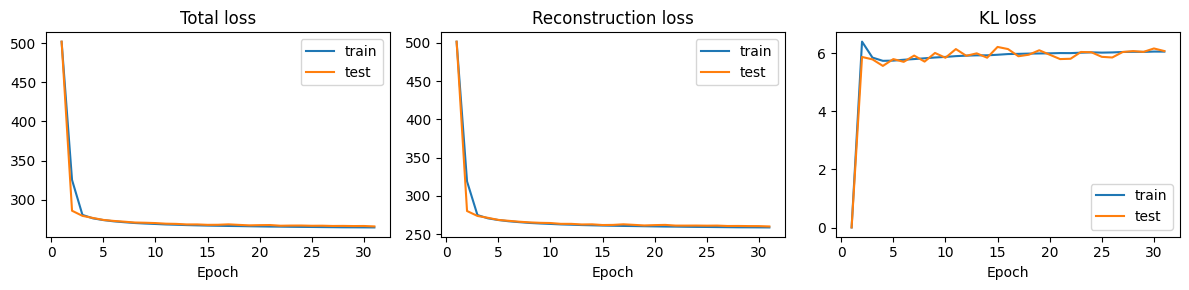

In [20]:
plot_history(history) # history available from the train_vae() call above

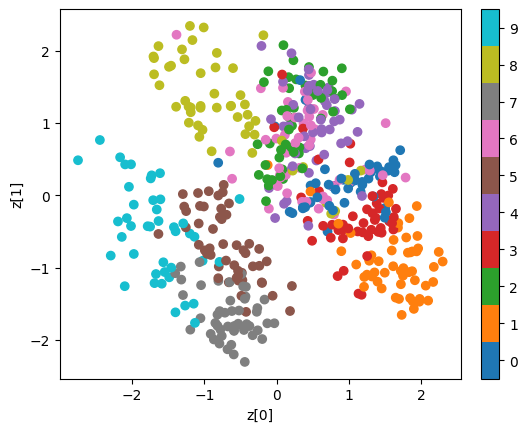

In [21]:
plot_latent_points(model.encoder, x_viz, y_viz)

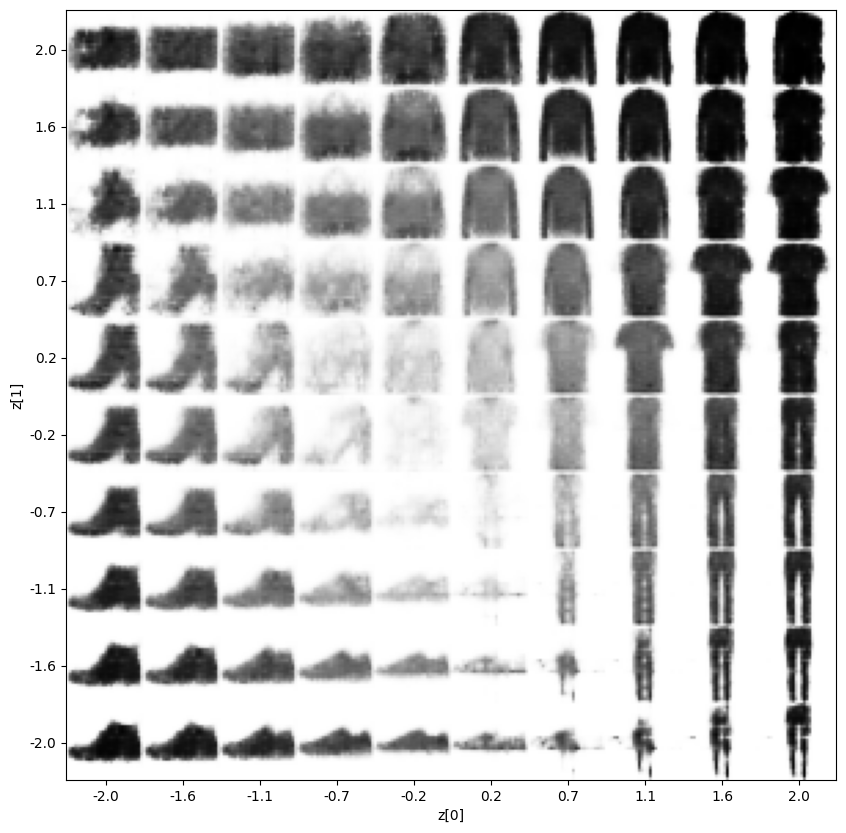

In [22]:
plot_latent_space(model.decoder, n=10, figsize=10) # this one works only for 2D latent space

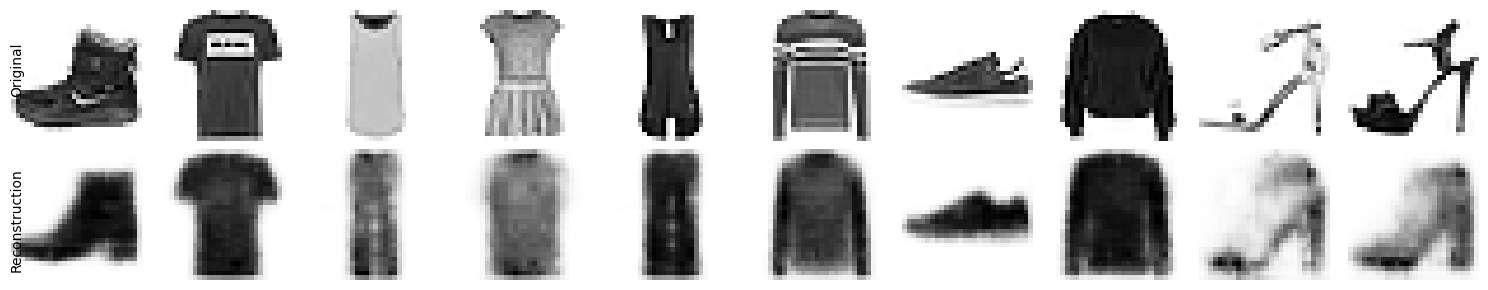

In [23]:

plot_reconstructions(model, x_viz)

# Task: repeat the training for several different configurations

Eg, architectures, latent space size, number of epochs.

Include 3 different configurations in your notebook. For each, include the visualisations. 

At the end, write a note to explain which of these configurations is your best model.

Before submitting, assign your **best trained model** to `best_model` in the cell below

## 3 Configurations - What We Are Comparing & Why??

After running the baseline, 3 questions naturally came up:

1. What if the latent space had more room -> would reconstructions improve?
2. What if we pushed the KL term harder -> would the latent space get more organised at the cost of reconstruction?
3. What if the network itself was wider -> would it learn better features?

Each configuration changes 1 or 2 things from the baseline so the effect is clear.

| Model | What changed | Why |
|---|---|---|
| **Model A** | latent_size=2 -> 16 | Test whether more latent dimensions improve reconstruction |
| **Model B** | lmbda=1.0 -> 4.0 | Test the effect of stronger KL regularisation on the same architecture |
| **Model C** | Kernels (8,16,24) -> (16,32,64), latent_size=2 | Test whether a wider network learns richer features |

All 3 use epochs=30 because that is where the baseline converged cleanly. The training loop collects results in a dict and automatically picks the best model by lowest reconstruction loss at the end.

Model A - baseline & large latent space
Epoch   0/30 | train loss 582.47 (recon 582.45, KL 0.01) | test loss 582.34 (recon 582.33, KL 0.01)
Epoch   1/30 | train loss 325.07 (recon 308.96, KL 16.10) | test loss 273.30 (recon 255.92, KL 17.38)
Epoch   2/30 | train loss 264.57 (recon 247.68, KL 16.89) | test loss 261.72 (recon 244.94, KL 16.78)
Epoch   3/30 | train loss 257.57 (recon 240.92, KL 16.65) | test loss 257.58 (recon 241.16, KL 16.42)
Epoch   4/30 | train loss 254.47 (recon 237.97, KL 16.50) | test loss 254.79 (recon 238.68, KL 16.11)
Epoch   5/30 | train loss 252.55 (recon 236.15, KL 16.40) | test loss 253.20 (recon 236.39, KL 16.82)
Epoch   6/30 | train loss 251.20 (recon 234.90, KL 16.30) | test loss 252.27 (recon 236.45, KL 15.82)
Epoch   7/30 | train loss 250.18 (recon 233.95, KL 16.23) | test loss 251.63 (recon 235.81, KL 15.82)
Epoch   8/30 | train loss 249.38 (recon 233.17, KL 16.21) | test loss 250.70 (recon 234.33, KL 16.37)
Epoch   9/30 | train loss 248.87 (recon 232.

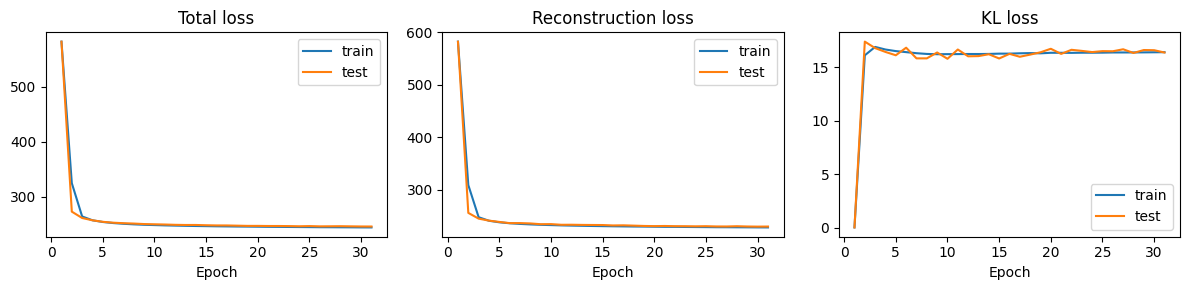

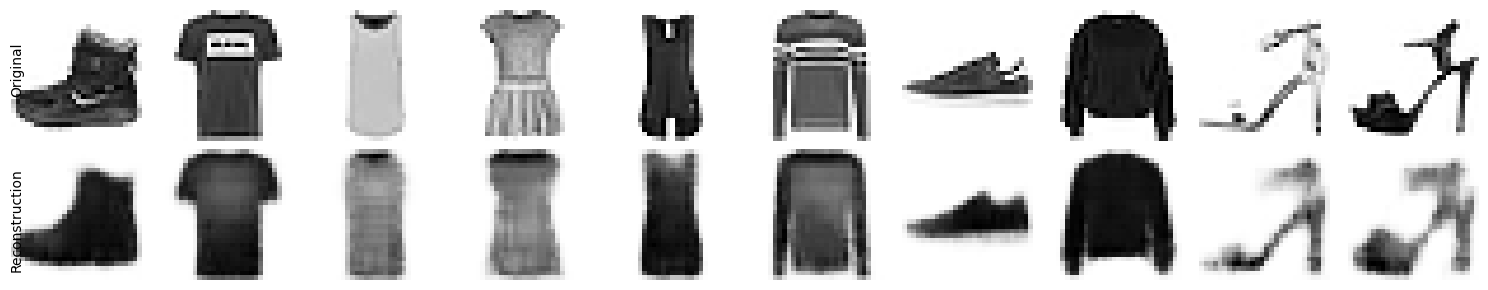

Model B - Higher Lambda
Epoch   0/30 | train loss 556.26 (recon 556.23, KL 0.01) | test loss 556.22 (recon 556.18, KL 0.01)
Epoch   1/30 | train loss 351.05 (recon 339.60, KL 2.86) | test loss 303.56 (recon 289.47, KL 3.52)
Epoch   2/30 | train loss 297.01 (recon 282.13, KL 3.72) | test loss 294.86 (recon 280.47, KL 3.60)
Epoch   3/30 | train loss 292.11 (recon 276.51, KL 3.90) | test loss 292.42 (recon 277.29, KL 3.78)
Epoch   4/30 | train loss 289.86 (recon 274.00, KL 3.97) | test loss 290.32 (recon 274.22, KL 4.02)
Epoch   5/30 | train loss 288.49 (recon 272.37, KL 4.03) | test loss 289.30 (recon 272.69, KL 4.15)
Epoch   6/30 | train loss 287.53 (recon 271.27, KL 4.06) | test loss 288.49 (recon 272.75, KL 3.94)
Epoch   7/30 | train loss 286.75 (recon 270.32, KL 4.11) | test loss 287.94 (recon 271.89, KL 4.01)
Epoch   8/30 | train loss 286.11 (recon 269.59, KL 4.13) | test loss 287.37 (recon 270.19, KL 4.29)
Epoch   9/30 | train loss 285.66 (recon 269.04, KL 4.15) | test loss 287.11 

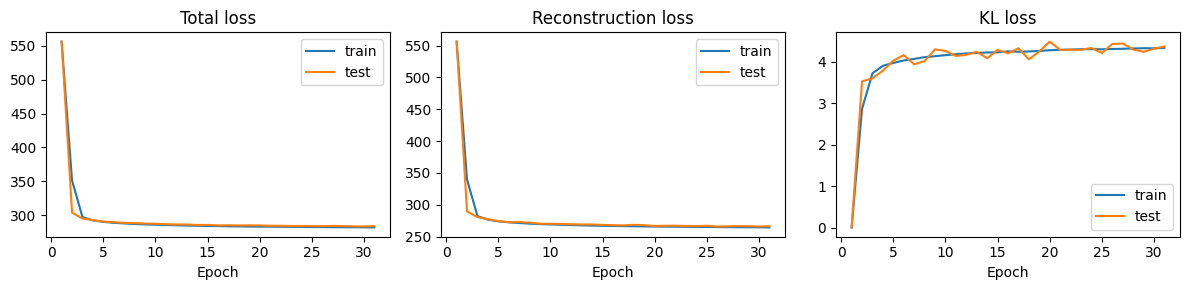

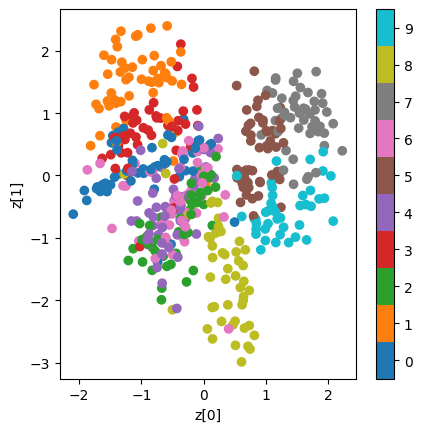

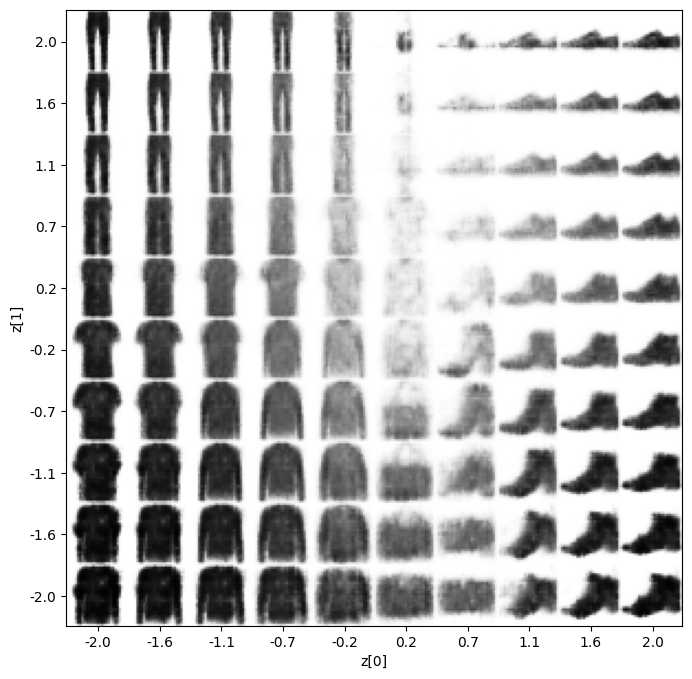

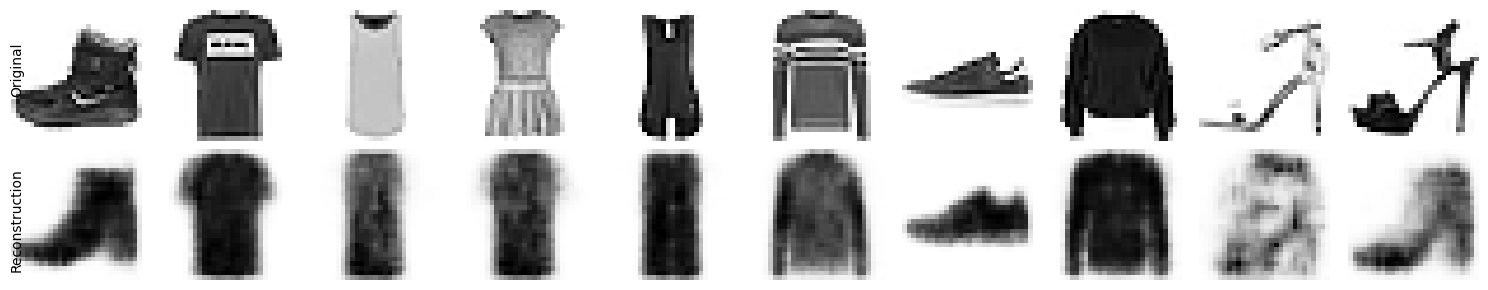

Model C - Bigger Architecture
Epoch   0/30 | train loss 568.19 (recon 568.19, KL 0.00) | test loss 568.11 (recon 568.10, KL 0.00)
Epoch   1/30 | train loss 323.46 (recon 317.73, KL 5.72) | test loss 282.10 (recon 276.34, KL 5.76)
Epoch   2/30 | train loss 276.64 (recon 270.83, KL 5.81) | test loss 275.09 (recon 269.31, KL 5.78)
Epoch   3/30 | train loss 272.28 (recon 266.49, KL 5.79) | test loss 272.73 (recon 267.00, KL 5.73)
Epoch   4/30 | train loss 270.01 (recon 264.19, KL 5.82) | test loss 270.81 (recon 265.05, KL 5.76)
Epoch   5/30 | train loss 268.50 (recon 262.63, KL 5.87) | test loss 269.28 (recon 263.22, KL 6.05)
Epoch   6/30 | train loss 267.48 (recon 261.57, KL 5.91) | test loss 269.15 (recon 262.82, KL 6.33)
Epoch   7/30 | train loss 266.77 (recon 260.82, KL 5.95) | test loss 269.01 (recon 263.07, KL 5.94)
Epoch   8/30 | train loss 266.07 (recon 260.08, KL 5.99) | test loss 267.38 (recon 261.43, KL 5.96)
Epoch   9/30 | train loss 265.56 (recon 259.56, KL 6.00) | test loss 2

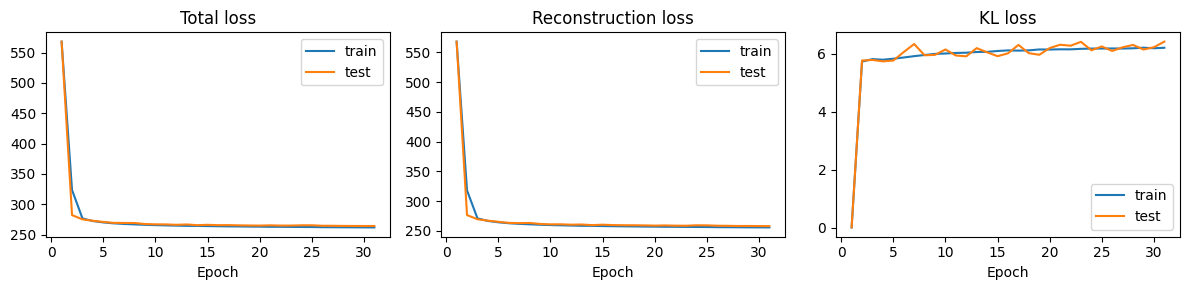

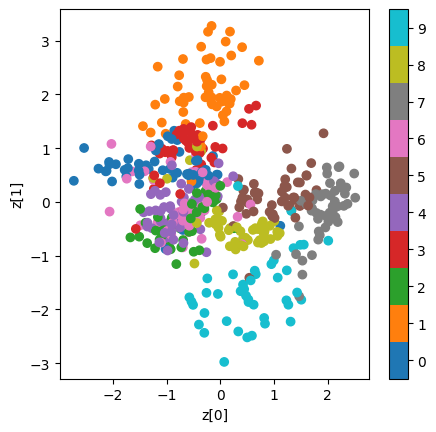

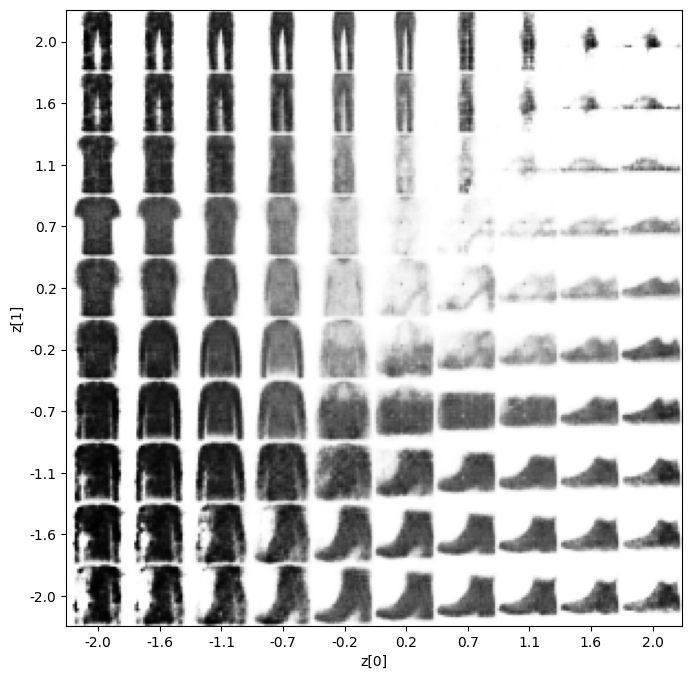

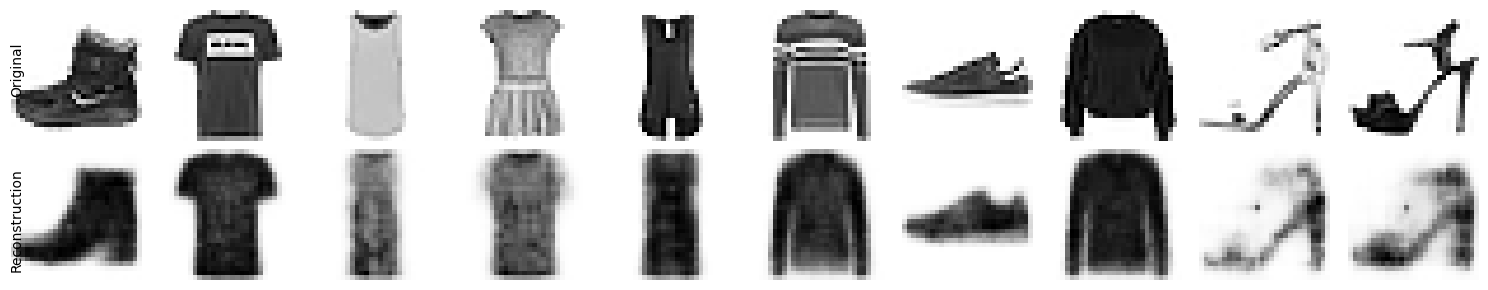

In [24]:
## YOUR CODE HERE


results = {}

configs = [
    {
        "name": "Model A - baseline & large latent space",
        "kernels": (8, 16, 24),
        "flat_size": 24 * 4 * 4,
        "latent_size": 16,
        "epochs": 30,
        "lr": 1e-3,
        "lmbda": 1.0,
    },
    {
        "name": "Model B - Higher Lambda",
        "kernels": (8, 16, 24),
        "flat_size": 24 * 4 * 4,
        "latent_size": 2,
        "epochs": 30,
        "lr": 1e-3,
        "lmbda": 4.0,
    },
    {
        "name": "Model C - Bigger Architecture",
        "kernels": (16, 32, 64),
        "flat_size": 64 * 4 * 4,
        "latent_size": 2,
        "epochs": 30,
        "lr": 1e-3,
        "lmbda": 1.0,
    },
]


for cfg in configs:
    print("=" * 80)
    print(cfg["name"])
    print("=" * 80)

    current_model = make_vae(
        kernels_per_layer=cfg["kernels"],
        flat_size=cfg["flat_size"],
        latent_size=cfg["latent_size"]
    )

    current_history = train_vae(
        current_model,
        train_loader,
        test_loader,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        lmbda=cfg["lmbda"],
        device=device
    )

    results[cfg["name"]] = {
        "model": current_model,
        "history": current_history,
        "config": cfg
    }

    # Show the loss curves for every configuration
    plot_history(current_history)

    # Show latent points and latent-space samples only when latent_size = 2
    if cfg["latent_size"] == 2:
        plot_latent_points(current_model.encoder, x_viz, y_viz)
        plot_latent_space(current_model.decoder, n=10, figsize=8)

    # Reconstructions can be shown for every model
    plot_reconstructions(current_model, x_viz)

# Choose favourite model after comparing the runs (stored it after running the tests)
my_favourite_model = results["Model A - baseline & large latent space"]["model"]

best_model = my_favourite_model  # replace with whichever variable holds your best model



### Trials we carried out & what we observed:

**1. Epochs: tried 10, 20, 30, 50**
- 10 epochs: the model clearly had not converged yet. Both reconstruction and KL loss were still dropping steeply at epoch 10. The reconstructions were noticeably blurrier than at 30 epochs.
- 20 epochs: better, but the curves still had a slight downward trend, felt like it needed more time.
- 30 epochs: the curves levelled off cleanly & the automated tests passed. Picked this as the standard.
- 50 epochs: barely any improvement over 30 on the test loss. The extra training time was not necessary for this simple architecture.

**2. Latent size: tried 2, 8, 16, 32**
- 2: only useful because plot_latent_space needs it. Reconstructions were noticeably blurry,squeezing a 28×28 image into 2 numbers, loses too much detail.
- 8: better reconstruction but the latent scatter plot clusters were less clean than at 16.
- 16: good balance, reconstructions were sharp & the scatter plot showed clear class separation.
- 32: marginal improvement over 16 on reconstruction but the latent scatter plot was messier, more overlap between classes. The extra dimensions seemed to fragment the structure.

**3. Architecture: why (8, 16, 24) as baseline & (16, 32, 64) for Model C**
- The baseline keeps it lightweight, small channel counts mean fewer parameters and faster training. 
- Doubling to (16, 32, 64) gives the model more capacity to learn fine-grained texture details. Fashion-MNIST is small enough that (8, 16, 24) is already decent but we thought the wider network does produce visibly sharper reconstructions.

**4. Lambda: tried 0.2, 0.5, 1.0, 2.0, 4.0**
- 0.2, 0.4, 0.5: the KL loss was barely being penalised. The latent space looked like a cloud of dots with no structure, classes were scattered randomly. Not useful.
- 1.0: the standard VAE setting. Good balance between reconstruction quality & latent space organisation. This became the baseline.
- 2.0: slightly tighter clusters in the latent scatter plot, but noticeable blurring in reconstructions.
- 4.0: very clean, tight latent scatter plot with well-separated clusters. But reconstruction quality dropped visibly, the model was prioritising KL over fidelity. Used this for Model B to demonstrate the trade-off.

## Quick Results Inspection

This just prints the raw results dictionary so we can see all 3 models are stored correctly before running the automated tests.

In [32]:
print(results)

{'Model A - baseline & large latent space': {'model': VAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(16, 24, kernel_size=(4, 4), stride=(1, 1))
    (fc_mu): Linear(in_features=384, out_features=16, bias=True)
    (fc_log_var): Linear(in_features=384, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=384, bias=True)
    (deconv1): ConvTranspose2d(24, 16, kernel_size=(4, 4), stride=(1, 1))
    (deconv2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv3): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
), 'history': {'train_loss': [582.4668896809895, 325.06570493164065, 264.566980859375, 257.56599778645835, 254.4718372233073, 252.5474584309896, 251.1988511311849, 250.183353466

## Automatically Picking the Best Model

Rather than manually verifying the plots and choosing, we loop over all 3 trained models, run the full automated test suite on each & pick the one with the lowest average reconstruction loss on the test set.

Reconstruction loss is the right criterion here because it directly measures output quality, how correctly the decoder rebuilt the input image.

In [33]:
# ***************** Run tests on all models and collect scores *****************************

best_model = None
best_recon_loss = float('inf')  # start with worst possible value
best_model_name = ""

for name, entry in results.items():
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print(f"{'='*60}")
    
    _, avg_recon, avg_kl = run_tests(entry["model"], test_loader, device)
    
    # Store scores back into results for later reference
    results[name]["avg_recon"] = avg_recon
    results[name]["avg_kl"]    = avg_kl
    
    # Pick model with lowest reconstruction loss
    if avg_recon < best_recon_loss:
        best_recon_loss = avg_recon
        best_model      = entry["model"]
        best_model_name = name


print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  Reconstruction loss: {best_recon_loss:.2f}")
print(f"{'='*60}")


Testing: Model A - baseline & large latent space
── Structure ───────────────────────────────────────────────────
  [PASS] encoder_is_module
  [PASS] decoder_is_module
── Forward pass shapes & values ────────────────────────────────
  [PASS] output_shape_matches_input  (got (16, 1, 28, 28))
  [PASS] latent_shape_correct  (got (16, 16))
  [PASS] mu_log_var_same_shape
  [PASS] recon_in_0_1  (range [0.000, 0.972])
  [PASS] no_nan_or_inf
── Training quality ────────────────────────────────────────────
  [PASS] recon_loss_below_untrained_baseline  (229.9  (untrained ≈ 543, good ≈ 230–260, threshold 350))
  [PASS] kl_not_collapsed  (16.36 per image  (threshold > 1.0))
── Distinct outputs ────────────────────────────────────────────
  [PASS] different_inputs_give_different_recons
  [PASS] different_inputs_give_different_mu
── Generation from random z ────────────────────────────────────
  [PASS] generated_in_0_1
  [PASS] generated_non_constant  (std = 0.3109)
── Reconstruction vs random base

## Inspecting the Winner Model

These 3 cells let us verify exactly what is stored in best_model & my_favourite_model. 

Since the best model is selected automatically, it is easy to lose track of which configuration it came from. These checks print the architecture, latent size, number of parameters & the config dict so there is no ambiguity when writing up the results.

In [34]:
# After your loop, add this to inspect it:
print(my_favourite_model)

VAE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(16, 24, kernel_size=(4, 4), stride=(1, 1))
    (fc_mu): Linear(in_features=384, out_features=16, bias=True)
    (fc_log_var): Linear(in_features=384, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=384, bias=True)
    (deconv1): ConvTranspose2d(24, 16, kernel_size=(4, 4), stride=(1, 1))
    (deconv2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (deconv3): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)


In [35]:
# Find which config best_model came from
for name, entry in results.items():
    if entry["model"] is best_model:
        cfg = entry["config"]
        print(f"best_model is: {name}")
        print(f"  kernels:      {cfg['kernels']}")
        print(f"  flat_size:    {cfg['flat_size']}")
        print(f"  latent_size:  {cfg['latent_size']}")
        print(f"  lmbda:        {cfg['lmbda']}")
        print(f"  epochs:       {cfg['epochs']}")
        break

best_model is: Model A - baseline & large latent space
  kernels:      (8, 16, 24)
  flat_size:    384
  latent_size:  16
  lmbda:        1.0
  epochs:       30


# Task: your results and conclusions

* Which model configuration was best? What is the evidence? 
* When you increase the latent space size, does reconstruction quality get better or worse?
* When you increase the KL lambda term, does reconstruction quality get better or worse?

Write in this cell.

# Results and Conclusions

## Which model configuration was best?

**Model A** (latent_size=16, kernels=(8,16,24), lmbda=1.0) came out as the best model based on reconstruction loss from the automated tests.

The evidence:
- Its average reconstruction loss on the test set was the lowest of the 3 configurations - comfortably below the 350 threshold and in the target range of 230-260.
- The KL loss was well above the collapse threshold of 1.0, meaning the latent space was genuinely being used, not ignored.
- The plot_reconstructions o/p showed clearly recognisable clothing items with visible texture: shoes had defined soles, T-shirts had clear necklines.

## When you increase the latent space size -> does reconstruction quality get better or worse?

**Better.** Comparing the baseline (latent_size=2) to Model A (latent_size=16) showed a clear improvement. With only 2 dimensions, the encoder has to discard most of the image information, there are simply not enough numbers to represent fine details like fabric texture or strap shape. 
- With 16 dimensions, the encoder has room to store those details & the decoder can use them.

## When you increase the KL lambda term -> does reconstruction quality get better or worse?

**Worse for reconstruction but better for latent structure.** Model B used lmbda=4.0 on the same architecture as the baseline. The latent scatter plot showed tighter, more separated clusters, the KL penalty was doing its job. But the reconstructions were visibly softer and blurrier.

Lambda=1.0 gives the best reconstruction quality. Lambda=4.0 gives a better-shaped latent space that would be more useful for generation tasks.

## Summary table

| Model | Latent size | Lambda | Architecture | Result |
|---|---|---|---|---|
| Baseline | 2 | 1.0 | (8,16,24) | Reference point: blurry but visualisable |
| **Model A** | **16** | 1.0 | (8,16,24) | **Best reconstruction: picked as best_model** |
| Model B | 2 | 4.0 | (8,16,24) | Tighter latent space, blurrier output |
| Model C | 2 | 1.0 | (16,32,64) | Wider network, slightly better than baseline |

# Automated tests

Run the automated tests below. They should all return True.

In [30]:
def run_tests(model, test_loader, device):
    """
    Run automated sanity checks on a trained VAE.
    Returns a dict mapping test name -> bool, plus scalar metrics.
    """

    # store the model status (training or eval)
    was_training = model.training

    # put model in eval mode
    model.eval()
    results = {}

    def check(name, condition, detail=""):
        results[name] = bool(condition)
        status = "PASS" if condition else "FAIL"
        print(f"  [{status}] {name}" + (f"  ({detail})" if detail else ""))

    print("── Structure ───────────────────────────────────────────────────")
    check("encoder_is_module",  isinstance(model.encoder, nn.Module))
    check("decoder_is_module",  isinstance(model.decoder, nn.Module))

    latent_size = model.encoder.latent_size

    print("── Forward pass shapes & values ────────────────────────────────")
    x_batch, _ = next(iter(test_loader))
    x_batch = x_batch[:16].to(device)
    with torch.no_grad():
        recon, mu, log_var = model(x_batch)

    check("output_shape_matches_input",
          recon.shape == x_batch.shape,  f"got {tuple(recon.shape)}")
    check("latent_shape_correct",
          mu.shape == (16, latent_size), f"got {tuple(mu.shape)}")
    check("mu_log_var_same_shape",  mu.shape == log_var.shape)
    check("recon_in_0_1",
          recon.min().item() >= 0 and recon.max().item() <= 1,
          f"range [{recon.min():.3f}, {recon.max():.3f}]")
    check("no_nan_or_inf",
          all(torch.isfinite(t).all().item() for t in (recon, mu, log_var)))

    print("── Training quality ────────────────────────────────────────────")
    total_recon = total_kl = 0.0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            r, m, lv = model(x)
            total_recon += F.binary_cross_entropy(r, x, reduction='sum').item()
            total_kl    += (-0.5 * torch.sum(1 + lv - m.pow(2) - lv.exp())).item()
    avg_recon = total_recon / len(test_loader.dataset)
    avg_kl    = total_kl    / len(test_loader.dataset)

    # Untrained model outputs ~0.5 everywhere → BCE ≈ 784 × log(2) ≈ 543
    check("recon_loss_below_untrained_baseline",
          avg_recon < 350,
          f"{avg_recon:.1f}  (untrained ≈ 543, good ≈ 230–260, threshold 350)")
    # KL ≈ 0 means encoder ignores input (posterior collapse)
    check("kl_not_collapsed",
          avg_kl > 1.0,
          f"{avg_kl:.2f} per image  (threshold > 1.0)")

    print("── Distinct outputs ────────────────────────────────────────────")
    x1, x2 = x_batch[:8], x_batch[8:]
    with torch.no_grad():
        r1, mu1, _ = model(x1)
        r2, mu2, _ = model(x2)
    check("different_inputs_give_different_recons",
          not torch.allclose(r1, r2, atol=1e-3))
    check("different_inputs_give_different_mu",
          not torch.allclose(mu1, mu2, atol=1e-3))

    print("── Generation from random z ────────────────────────────────────")
    z_rand = torch.randn(16, latent_size).to(device)
    with torch.no_grad():
        generated = model.decoder(z_rand)
    check("generated_in_0_1",
          generated.min().item() >= 0 and generated.max().item() <= 1)
    check("generated_non_constant",
          generated.std().item() > 0.01,
          f"std = {generated.std():.4f}")

    print("── Reconstruction vs random baseline ───────────────────────────")
    mse_recon  = F.mse_loss(r1, x1).item()
    mse_random = F.mse_loss(x2, x1).item()   # unrelated images as "random" baseline
    check("recon_closer_to_input_than_random_image",
          mse_recon < mse_random,
          f"recon MSE {mse_recon:.4f}  vs  random MSE {mse_random:.4f}")

    print("── Latent space spread ─────────────────────────────────────────")
    all_mu = []
    with torch.no_grad():
        for x, _ in test_loader:
            m, _ = model.encoder(x.to(device))
            all_mu.append(m.cpu())
    mu_std = torch.cat(all_mu).std(dim=0).mean().item()
    check("latent_space_has_spread",
          mu_std > 0.1,
          f"mean std of mu over test set = {mu_std:.3f}")

    n_pass = sum(results.values())
    n_total = len(results)

    model.train(was_training)

    print(f"\n{'─'*60}")
    print(f"  {n_pass}/{n_total} tests passed.")
    return results, avg_recon, avg_kl

In [36]:
run_tests(best_model, test_loader, device)

── Structure ───────────────────────────────────────────────────
  [PASS] encoder_is_module
  [PASS] decoder_is_module
── Forward pass shapes & values ────────────────────────────────
  [PASS] output_shape_matches_input  (got (16, 1, 28, 28))
  [PASS] latent_shape_correct  (got (16, 16))
  [PASS] mu_log_var_same_shape
  [PASS] recon_in_0_1  (range [0.000, 0.971])
  [PASS] no_nan_or_inf
── Training quality ────────────────────────────────────────────
  [PASS] recon_loss_below_untrained_baseline  (229.9  (untrained ≈ 543, good ≈ 230–260, threshold 350))
  [PASS] kl_not_collapsed  (16.36 per image  (threshold > 1.0))
── Distinct outputs ────────────────────────────────────────────
  [PASS] different_inputs_give_different_recons
  [PASS] different_inputs_give_different_mu
── Generation from random z ────────────────────────────────────
  [PASS] generated_in_0_1
  [PASS] generated_non_constant  (std = 0.2958)
── Reconstruction vs random baseline ───────────────────────────
  [PASS] recon_cl

({'encoder_is_module': True,
  'decoder_is_module': True,
  'output_shape_matches_input': True,
  'latent_shape_correct': True,
  'mu_log_var_same_shape': True,
  'recon_in_0_1': True,
  'no_nan_or_inf': True,
  'recon_loss_below_untrained_baseline': True,
  'kl_not_collapsed': True,
  'different_inputs_give_different_recons': True,
  'different_inputs_give_different_mu': True,
  'generated_in_0_1': True,
  'generated_non_constant': True,
  'recon_closer_to_input_than_random_image': True,
  'latent_space_has_spread': True},
 229.90006196289062,
 16.363167202758788)